<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/DualDecoder_UNet_CrossAttn_Containment_REFUGE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Decoder U-Net (Y-Net) + Cross-Attention + Containment Loss — REFUGE (3-class)

**Base model:** one *shared* U-Net encoder + bottleneck feeding **two parallel decoders**
- **Disc head:** background vs whole optic disc (disc+cup)
- **Cup head:** background vs optic cup

**This version adds two things:**
1. **Cross-attention (co-attention)** between the disc and cup decoders at the coarsest
   decoder stage — the two pipelines *exchange information* (disc ↔ cup) instead of
   running blind in parallel.
2. **Containment loss** — a differentiable penalty that pushes the predicted cup to lie
   **inside** the predicted disc (cup ⊆ disc), enforced during training rather than only
   at fusion time.




In [1]:
# ============================================================
# CELL 0 — Environment setup
# Imports, fixed seeds for reproducibility, device, and global config.
# ============================================================
!pip install -q albumentations

import os, cv2, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy import ndimage

# --- reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE  = 256                                   # 256 -> 384 -> 512 (change for higher-res runs)
SAVE_PATH = "/kaggle/working/best_dualunet_xattn.pth"
print("Device:", DEVICE, "| IMG_SIZE:", IMG_SIZE)

Device: cuda | IMG_SIZE: 256


In [2]:
# ============================================================
# CELL 1 — Get the REFUGE dataset (auto-download)
# Just run this cell. It downloads the glaucoma-datasets via kagglehub and
# points DATA_ROOT at the REFUGE folder. (Turn ON Internet in the right panel:
# Settings -> Internet.) If you already attached it via "Add Input", it uses that.
# ============================================================
!pip install -q kagglehub

import glob, os
DATA_ROOT = None

# 1) already attached on Kaggle (Add Input)?  use it, no download needed
_cands = glob.glob("/kaggle/input/**/REFUGE", recursive=True)
if _cands:
    DATA_ROOT = _cands[0]
    print("Found attached dataset.")
else:
    # 2) otherwise download it (works on Kaggle & Colab)
    import kagglehub
    _path = kagglehub.dataset_download("arnavjain1/glaucoma-datasets")
    print("Downloaded to:", _path)
    _cands = glob.glob(os.path.join(_path, "**", "REFUGE"), recursive=True)
    DATA_ROOT = _cands[0] if _cands else os.path.join(_path, "REFUGE")

print("Using DATA_ROOT:", DATA_ROOT)
assert os.path.isdir(DATA_ROOT), "REFUGE folder not found - check the dataset / Internet setting"

Using Colab cache for faster access to the 'glaucoma-datasets' dataset.
Downloaded to: /kaggle/input/glaucoma-datasets
Using DATA_ROOT: /kaggle/input/glaucoma-datasets/REFUGE


In [3]:
# ============================================================
# CELL 2 — Base REFUGE dataset (raw 3-class masks)
# Mask pixel values: 0 = background, 1 = optic disc (rim), 2 = optic cup
# Returns the FULL 3-class mask; split into two binary tasks in CELL 4.
# ============================================================
class REFUGEDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir, self.mask_dir, self.transform = img_dir, mask_dir, transform
        self.filenames = []
        for f in sorted(os.listdir(img_dir)):
            base = os.path.splitext(f)[0]
            mp = os.path.join(mask_dir, base + ".png")
            if os.path.exists(mp):
                self.filenames.append((f, base + ".png"))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_UNCHANGED)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]
        return image, mask.long()               # image: 3xHxW float, mask: HxW long

In [4]:
# ============================================================
# CELL 3 — Augmentations + base datasets
# Train: flips/rotate/brightness for robustness. Val/test: resize + normalize only.
# ============================================================
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

train_ds = REFUGEDataset(f"{DATA_ROOT}/train/Images_Cropped", f"{DATA_ROOT}/train/Masks_Cropped", train_transform)
val_ds   = REFUGEDataset(f"{DATA_ROOT}/val/Images_Cropped",   f"{DATA_ROOT}/val/Masks_Cropped",   val_transform)
test_ds  = REFUGEDataset(f"{DATA_ROOT}/test/Images_Cropped",  f"{DATA_ROOT}/test/Masks_Cropped",  val_transform)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 400 Val: 400 Test: 400


In [5]:
# ============================================================
# CELL 4 — Dual-task wrapper: split 3-class mask into TWO binary masks
#   disc_m : 1 where (mask > 0)   == whole optic disc (disc+cup)   [Pipeline 1]
#   cup_m  : 1 where (mask == 2)  == optic cup only                [Pipeline 2]
# NOTE: for higher resolutions drop batch_size (T4/P100 16GB):
#   256 -> 8   |   384 -> 4   |   512 -> 2
# ============================================================
class DualTaskDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        image, mask3 = self.base[idx]
        disc_m = (mask3 > 0).long()     # bg vs DISC (disc+cup)
        cup_m  = (mask3 == 2).long()    # bg vs CUP
        return image, disc_m, cup_m

BATCH_SIZE = 8      # <-- 4 for 384, 2 for 512

train_ds_dual = DualTaskDataset(train_ds)
val_ds_dual   = DualTaskDataset(val_ds)
test_ds_dual  = DualTaskDataset(test_ds)

train_loader = DataLoader(train_ds_dual, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds_dual,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds_dual,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

imgs, disc_m, cup_m = next(iter(train_loader))
print("img:", imgs.shape, "| disc:", disc_m.shape, torch.unique(disc_m).tolist(),
      "| cup:", cup_m.shape, torch.unique(cup_m).tolist())

img: torch.Size([8, 3, 256, 256]) | disc: torch.Size([8, 256, 256]) [0, 1] | cup: torch.Size([8, 256, 256]) [0, 1]


In [6]:
# ============================================================
# CELL 5 — Metrics (per binary head) + dual evaluation helper
# evaluate_dual returns SEPARATE metric dicts for the disc and cup pipelines.
# Reported loss now includes the containment term (defined in CELL 6) so that
# train/val/test losses are all consistent with the training objective.
# ============================================================
@torch.no_grad()
def compute_all_metrics(logits, targets, num_classes=2, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    m = {k: [] for k in ["dice","iou","precision","recall","f1"]}
    for c in range(num_classes):
        pred_c, target_c = (preds == c), (targets == c)
        tp = (pred_c & target_c).sum().float()
        fp = (pred_c & ~target_c).sum().float()
        fn = (~pred_c & target_c).sum().float()
        precision = (tp+smooth)/(tp+fp+smooth)
        recall    = (tp+smooth)/(tp+fn+smooth)
        m["dice"].append(((2*tp+smooth)/(2*tp+fp+fn+smooth)).item())
        m["iou"].append(((tp+smooth)/(tp+fp+fn+smooth)).item())
        m["precision"].append(precision.item())
        m["recall"].append(recall.item())
        m["f1"].append(((2*precision*recall)/(precision+recall+smooth)).item())
    m["accuracy"] = (preds == targets).float().mean().item()
    return m

@torch.no_grad()
def evaluate_dual(model, loader, criterion, device=DEVICE):
    """Return (avg_loss, disc_metrics, cup_metrics) — pipelines scored separately."""
    model.eval()
    running_loss = 0.0
    keys = ["dice","iou","precision","recall","f1"]
    agg_disc = {k: np.zeros(2) for k in keys}; agg_disc["accuracy"] = 0.0
    agg_cup  = {k: np.zeros(2) for k in keys}; agg_cup["accuracy"]  = 0.0
    n_batches = 0
    for imgs, disc_m, cup_m in loader:
        imgs, disc_m, cup_m = imgs.to(device), disc_m.to(device), cup_m.to(device)
        out_disc, out_cup = model(imgs)
        loss = (criterion(out_disc, disc_m) + criterion(out_cup, cup_m)
                + LAMBDA_CONTAIN * containment_loss(out_disc, out_cup))     # incl. containment
        running_loss += loss.item() * imgs.size(0)
        md_ = compute_all_metrics(out_disc, disc_m)
        mc_ = compute_all_metrics(out_cup,  cup_m)
        for k in keys:
            agg_disc[k] += np.array(md_[k]); agg_cup[k] += np.array(mc_[k])
        agg_disc["accuracy"] += md_["accuracy"]; agg_cup["accuracy"] += mc_["accuracy"]
        n_batches += 1
    for k in keys:
        agg_disc[k] /= n_batches; agg_cup[k] /= n_batches
    agg_disc["accuracy"] /= n_batches; agg_cup["accuracy"] /= n_batches
    return running_loss/len(loader.dataset), agg_disc, agg_cup

In [7]:
# ============================================================
# CELL 6 — Losses
# DiceLoss: soft multi-class Dice. CombinedLoss: 0.5*CE + 0.5*Dice (per head).
# containment_loss: differentiable penalty so the CUP stays INSIDE the DISC.
#   cup must satisfy  P(cup) <= P(disc)  at every pixel; we penalise the excess.
# ============================================================
class DiceLoss(nn.Module):
    def __init__(self, num_classes=2, smooth=1e-6):
        super().__init__()
        self.num_classes, self.smooth = num_classes, smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, self.num_classes).permute(0,3,1,2).float()
        inter = torch.sum(probs*targets_oh, (0,2,3))
        union = torch.sum(probs+targets_oh, (0,2,3))
        return 1 - ((2*inter+self.smooth)/(union+self.smooth)).mean()

class CombinedLoss(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

# ---- containment: penalise cup probability lying OUTSIDE the disc (cup ⊆ disc) ----
LAMBDA_CONTAIN = 0.5                              # weight of containment in the joint loss
def containment_loss(out_disc, out_cup):
    p_disc = F.softmax(out_disc, dim=1)[:, 1]     # P(disc)  [B,H,W]
    p_cup  = F.softmax(out_cup,  dim=1)[:, 1]     # P(cup)
    return F.relu(p_cup - p_disc).mean()          # excess cup-prob outside the disc

In [8]:
# ============================================================
# CELL 7 — Dual-Decoder U-Net (Y-Net) + CROSS-ATTENTION between decoders
# Shared encoder/bottleneck -> two decoders that EXCHANGE info at the coarsest
# decoder stage via bidirectional cross-attention (co-attention):
#     disc stream  <-- attends to -->  cup stream
# Still returns (disc_logits, cup_logits), so all later cells are unchanged.
# ============================================================
class DoubleConv(nn.Module):
    """(Conv3x3 -> BN -> ReLU) x2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class CrossAttention2D(nn.Module):
    """Multi-head cross-attention on 2D feature maps.
       query stream `x` attends to context stream `ctx`; residual add back to x."""
    def __init__(self, dim, heads=4):
        super().__init__()
        assert dim % heads == 0
        self.heads, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.norm_q   = nn.GroupNorm(1, dim)
        self.norm_ctx = nn.GroupNorm(1, dim)
        self.to_q = nn.Conv2d(dim, dim, 1)
        self.to_k = nn.Conv2d(dim, dim, 1)
        self.to_v = nn.Conv2d(dim, dim, 1)
        self.proj = nn.Conv2d(dim, dim, 1)
    def forward(self, x, ctx):
        B, C, H, W = x.shape
        xn, cn = self.norm_q(x), self.norm_ctx(ctx)
        q, k, v = self.to_q(xn), self.to_k(cn), self.to_v(cn)
        def split_heads(t):                       # (B,C,H,W) -> (B, heads, HW, dh)
            return t.view(B, self.heads, self.dh, H * W).permute(0, 1, 3, 2)
        q, k, v = split_heads(q), split_heads(k), split_heads(v)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = attn @ v                            # (B, heads, HW, dh)
        out = out.permute(0, 1, 3, 2).reshape(B, C, H, W)
        return x + self.proj(out)                 # residual

class CrossTalk(nn.Module):
    """Bidirectional exchange: disc attends to cup AND cup attends to disc.
       Both use the ORIGINAL features as context (no ordering bias)."""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.disc_from_cup = CrossAttention2D(dim, heads)
        self.cup_from_disc = CrossAttention2D(dim, heads)
    def forward(self, f_disc, f_cup):
        d = self.disc_from_cup(f_disc, f_cup)
        c = self.cup_from_disc(f_cup, f_disc)
        return d, c

class Decoder(nn.Module):
    """One U-Net decoder branch. Its layers are driven stage-by-stage by the parent
       so cross-attention can be injected between the two branches."""
    def __init__(self, base_ch=64, num_classes=2):
        super().__init__()
        C1, C2, C3, C4 = base_ch, base_ch*2, base_ch*4, base_ch*8
        self.up4 = nn.ConvTranspose2d(C4*2, C4, 2, stride=2); self.dec4 = DoubleConv(C4*2, C4)
        self.up3 = nn.ConvTranspose2d(C4,   C3, 2, stride=2); self.dec3 = DoubleConv(C3*2, C3)
        self.up2 = nn.ConvTranspose2d(C3,   C2, 2, stride=2); self.dec2 = DoubleConv(C2*2, C2)
        self.up1 = nn.ConvTranspose2d(C2,   C1, 2, stride=2); self.dec1 = DoubleConv(C1*2, C1)
        self.head = nn.Conv2d(C1, num_classes, 1)

class DualDecoderUNet(nn.Module):
    """Shared encoder/bottleneck + two decoders with a cross-attention exchange
       at the coarsest decoder stage."""
    def __init__(self, in_ch=3, base_ch=64, num_classes=2, heads=4):
        super().__init__()
        C1, C2, C3, C4 = base_ch, base_ch*2, base_ch*4, base_ch*8
        # shared encoder
        self.enc1 = DoubleConv(in_ch, C1)
        self.enc2 = DoubleConv(C1, C2)
        self.enc3 = DoubleConv(C2, C3)
        self.enc4 = DoubleConv(C3, C4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(C4, C4*2)
        # two decoders
        self.disc_decoder = Decoder(base_ch, num_classes)
        self.cup_decoder  = Decoder(base_ch, num_classes)
        # cross-attention exchange at the coarsest decoder stage (C4 channels)
        self.crosstalk4 = CrossTalk(C4, heads=heads)
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        dd, cd = self.disc_decoder, self.cup_decoder
        # coarsest stage for both branches
        d4 = dd.dec4(torch.cat([dd.up4(b), e4], 1))
        c4 = cd.dec4(torch.cat([cd.up4(b), e4], 1))
        d4, c4 = self.crosstalk4(d4, c4)                     # <-- CROSS-ATTENTION
        # remaining stages, in lockstep
        d3 = dd.dec3(torch.cat([dd.up3(d4), e3], 1)); c3 = cd.dec3(torch.cat([cd.up3(c4), e3], 1))
        d2 = dd.dec2(torch.cat([dd.up2(d3), e2], 1)); c2 = cd.dec2(torch.cat([cd.up2(c3), e2], 1))
        d1 = dd.dec1(torch.cat([dd.up1(d2), e1], 1)); c1 = cd.dec1(torch.cat([cd.up1(c2), e1], 1))
        return dd.head(d1), cd.head(c1)

# sanity check
_m = DualDecoderUNet().to(DEVICE)
_od, _oc = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print("disc head:", _od.shape, "| cup head:", _oc.shape)
print("params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))
del _m, _od, _oc

disc head: torch.Size([2, 2, 256, 256]) | cup head: torch.Size([2, 2, 256, 256])
params: 45341380


In [13]:
import os
# ============================================================
# CELL 8 — Training loop (dual head + containment)
# Loss per step = disc_loss + cup_loss + LAMBDA_CONTAIN * containment.
# Prints Dice of BOTH pipelines separately for BOTH train and val each epoch.
# Best checkpoint = highest mean foreground Dice = (disc_fg + cup_fg)/2 on val.
# ============================================================
def train_dual(model, train_loader, val_loader,
               num_epochs=150, patience=25, lr=1e-3,
               save_path=SAVE_PATH):

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = CombinedLoss(2)

    history = {"train_loss": [], "val_loss": []}
    for split in ["train","val"]:
        for head in ["disc","cup"]:
            for c in range(2):
                history[f"{split}_{head}_dice_c{c}"] = []
    history["val_mean_fg"] = []

    best_mean, no_improve = 0.0, 0
    print("="*70,
          f"\nTraining Dual-Decoder U-Net + Cross-Attention (containment \u03bb={LAMBDA_CONTAIN})\n",
          "="*70, sep="")
    for epoch in range(1, num_epochs+1):
        # ---------- train one epoch ----------
        model.train()
        running = 0.0
        for imgs, disc_m, cup_m in train_loader:
            imgs, disc_m, cup_m = imgs.to(DEVICE), disc_m.to(DEVICE), cup_m.to(DEVICE)
            optimizer.zero_grad()
            out_disc, out_cup = model(imgs)
            loss = (criterion(out_disc, disc_m) + criterion(out_cup, cup_m)
                    + LAMBDA_CONTAIN * containment_loss(out_disc, out_cup))   # joint + containment
            loss.backward(); optimizer.step()
            running += loss.item() * imgs.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---------- evaluate on train + val (both heads separately) ----------
        _,        tr_disc, tr_cup = evaluate_dual(model, train_loader, criterion)
        val_loss, va_disc, va_cup = evaluate_dual(model, val_loader,   criterion)
        scheduler.step()

        # ---------- log history ----------
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        for c in range(2):
            history[f"train_disc_dice_c{c}"].append(tr_disc["dice"][c])
            history[f"train_cup_dice_c{c}"].append(tr_cup["dice"][c])
            history[f"val_disc_dice_c{c}"].append(va_disc["dice"][c])
            history[f"val_cup_dice_c{c}"].append(va_cup["dice"][c])
        mean_fg = (va_disc["dice"][1] + va_cup["dice"][1]) / 2
        history["val_mean_fg"].append(mean_fg)

        # ---------- print (both pipelines, train + val) ----------
        print(f"Ep {epoch:3d}/{num_epochs} | TrLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | ValMeanFG:{mean_fg:.4f}")
        print(f"   DISC head [bg, disc] -> Train Dice:{np.round(tr_disc['dice'],3)} | Val Dice:{np.round(va_disc['dice'],3)}")
        print(f"   CUP  head [bg, cup ] -> Train Dice:{np.round(tr_cup['dice'],3)} | Val Dice:{np.round(va_cup['dice'],3)}")

        # ---------- checkpoint on best val mean-foreground Dice ----------
        if mean_fg > best_mean:
            best_mean, no_improve = mean_fg, 0
            torch.save(model.state_dict(), save_path)
            print(f"   -> best saved (mean FG Dice = {best_mean:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    return history

In [14]:
# ============================================================
# CELL 9 — Build the model and train it
# ============================================================
model = DualDecoderUNet(in_ch=3, base_ch=64, num_classes=2, heads=4).to(DEVICE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

history = train_dual(model, train_loader, val_loader,
                     num_epochs=150, patience=25, lr=1e-3,
                     save_path=SAVE_PATH)

Trainable params: 45341380
Training Dual-Decoder U-Net + Cross-Attention (containment λ=0.5)
Ep   1/150 | TrLoss:0.6319 | ValLoss:0.7983 | ValMeanFG:0.6968
   DISC head [bg, disc] -> Train Dice:[0.631 0.889] | Val Dice:[0.685 0.853]
   CUP  head [bg, cup ] -> Train Dice:[0.815 0.553] | Val Dice:[0.88  0.541]
   -> best saved (mean FG Dice = 0.6968)
Ep   2/150 | TrLoss:0.4320 | ValLoss:0.4785 | ValMeanFG:0.8023
   DISC head [bg, disc] -> Train Dice:[0.856 0.94 ] | Val Dice:[0.835 0.907]
   CUP  head [bg, cup ] -> Train Dice:[0.94  0.756] | Val Dice:[0.943 0.697]
   -> best saved (mean FG Dice = 0.8023)
Ep   3/150 | TrLoss:0.3316 | ValLoss:0.4454 | ValMeanFG:0.8259
   DISC head [bg, disc] -> Train Dice:[0.855 0.939] | Val Dice:[0.809 0.915]
   CUP  head [bg, cup ] -> Train Dice:[0.958 0.81 ] | Val Dice:[0.944 0.737]
   -> best saved (mean FG Dice = 0.8259)
Ep   4/150 | TrLoss:0.3134 | ValLoss:0.4539 | ValMeanFG:0.8513
   DISC head [bg, disc] -> Train Dice:[0.876 0.951] | Val Dice:[0.843 

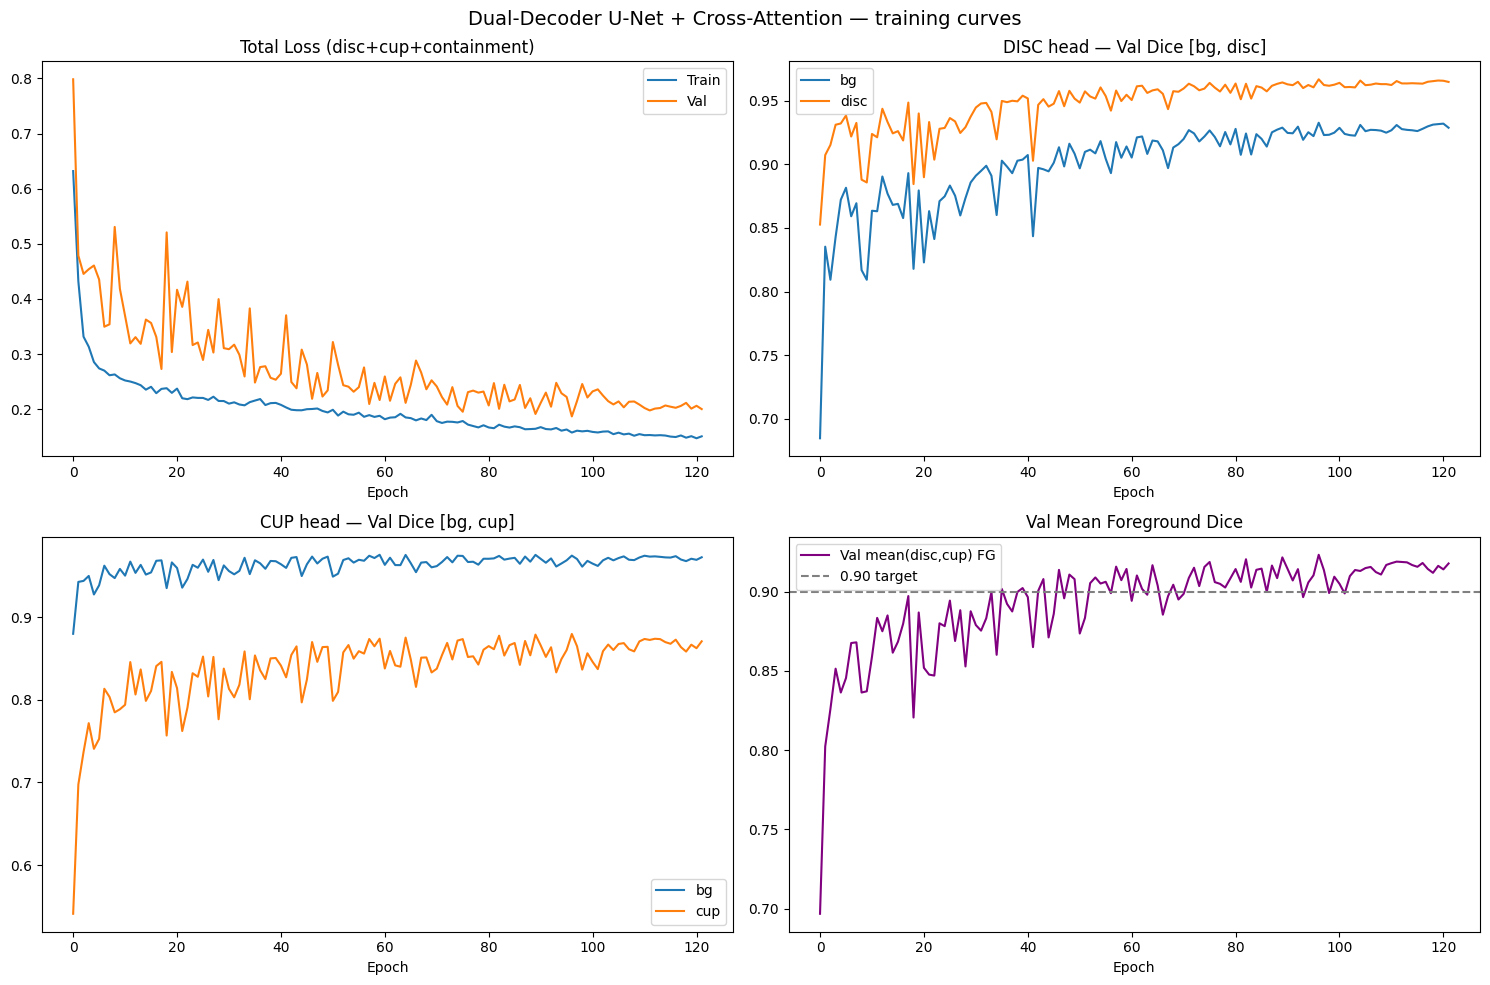

In [15]:
# ============================================================
# CELL 10 — Training curves (both pipelines separately)
# ============================================================
def plot_dual_curves(history):
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Dual-Decoder U-Net + Cross-Attention — training curves", fontsize=14)

    ax[0,0].plot(history["train_loss"], label="Train")
    ax[0,0].plot(history["val_loss"],   label="Val")
    ax[0,0].set_title("Total Loss (disc+cup+containment)"); ax[0,0].legend(); ax[0,0].set_xlabel("Epoch")

    ax[0,1].plot(history["val_disc_dice_c0"], label="bg")
    ax[0,1].plot(history["val_disc_dice_c1"], label="disc")
    ax[0,1].set_title("DISC head — Val Dice [bg, disc]"); ax[0,1].legend(); ax[0,1].set_xlabel("Epoch")

    ax[1,0].plot(history["val_cup_dice_c0"], label="bg")
    ax[1,0].plot(history["val_cup_dice_c1"], label="cup")
    ax[1,0].set_title("CUP head — Val Dice [bg, cup]"); ax[1,0].legend(); ax[1,0].set_xlabel("Epoch")

    ax[1,1].plot(history["val_mean_fg"], color="purple", label="Val mean(disc,cup) FG")
    ax[1,1].axhline(0.90, color="gray", ls="--", label="0.90 target")
    ax[1,1].set_title("Val Mean Foreground Dice"); ax[1,1].legend(); ax[1,1].set_xlabel("Epoch")

    plt.tight_layout(); plt.savefig("/kaggle/working/dualunet_xattn_curves.png", dpi=100); plt.show()

plot_dual_curves(history)

In [16]:
# ============================================================
# CELL 11 — TEST-set evaluation (the two pipelines reported SEPARATELY)
# Loads the best checkpoint and prints full metrics for each pipeline.
# ============================================================
model.load_state_dict(torch.load(SAVE_PATH)); model.eval()
criterion = CombinedLoss(2)

test_loss, test_disc, test_cup = evaluate_dual(model, test_loader, criterion)

def print_pipeline(name, fg_label, m):
    print("="*55)
    print(f"{name} PIPELINE — TEST RESULTS   (classes: bg, {fg_label})")
    print("="*55)
    print(f"Accuracy : {m['accuracy']:.4f}")
    print(f"Dice     -> bg:{m['dice'][0]:.4f} | {fg_label}:{m['dice'][1]:.4f}")
    print(f"IoU      -> bg:{m['iou'][0]:.4f} | {fg_label}:{m['iou'][1]:.4f}")
    print(f"Precision-> bg:{m['precision'][0]:.4f} | {fg_label}:{m['precision'][1]:.4f}")
    print(f"Recall   -> bg:{m['recall'][0]:.4f} | {fg_label}:{m['recall'][1]:.4f}")
    print(f"F1       -> bg:{m['f1'][0]:.4f} | {fg_label}:{m['f1'][1]:.4f}")

print(f"Test total loss (disc+cup+containment): {test_loss:.4f}\n")
print_pipeline("DISC", "disc", test_disc)
print()
print_pipeline("CUP",  "cup",  test_cup)

Test total loss (disc+cup+containment): 0.2035

DISC PIPELINE — TEST RESULTS   (classes: bg, disc)
Accuracy : 0.9526
Dice     -> bg:0.9281 | disc:0.9645
IoU      -> bg:0.8661 | disc:0.9315
Precision-> bg:0.9495 | disc:0.9539
Recall   -> bg:0.9081 | disc:0.9755
F1       -> bg:0.9281 | disc:0.9645

CUP PIPELINE — TEST RESULTS   (classes: bg, cup)
Accuracy : 0.9517
Dice     -> bg:0.9703 | cup:0.8684
IoU      -> bg:0.9424 | cup:0.7684
Precision-> bg:0.9857 | cup:0.8134
Recall   -> bg:0.9555 | cup:0.9338
F1       -> bg:0.9703 | cup:0.8684


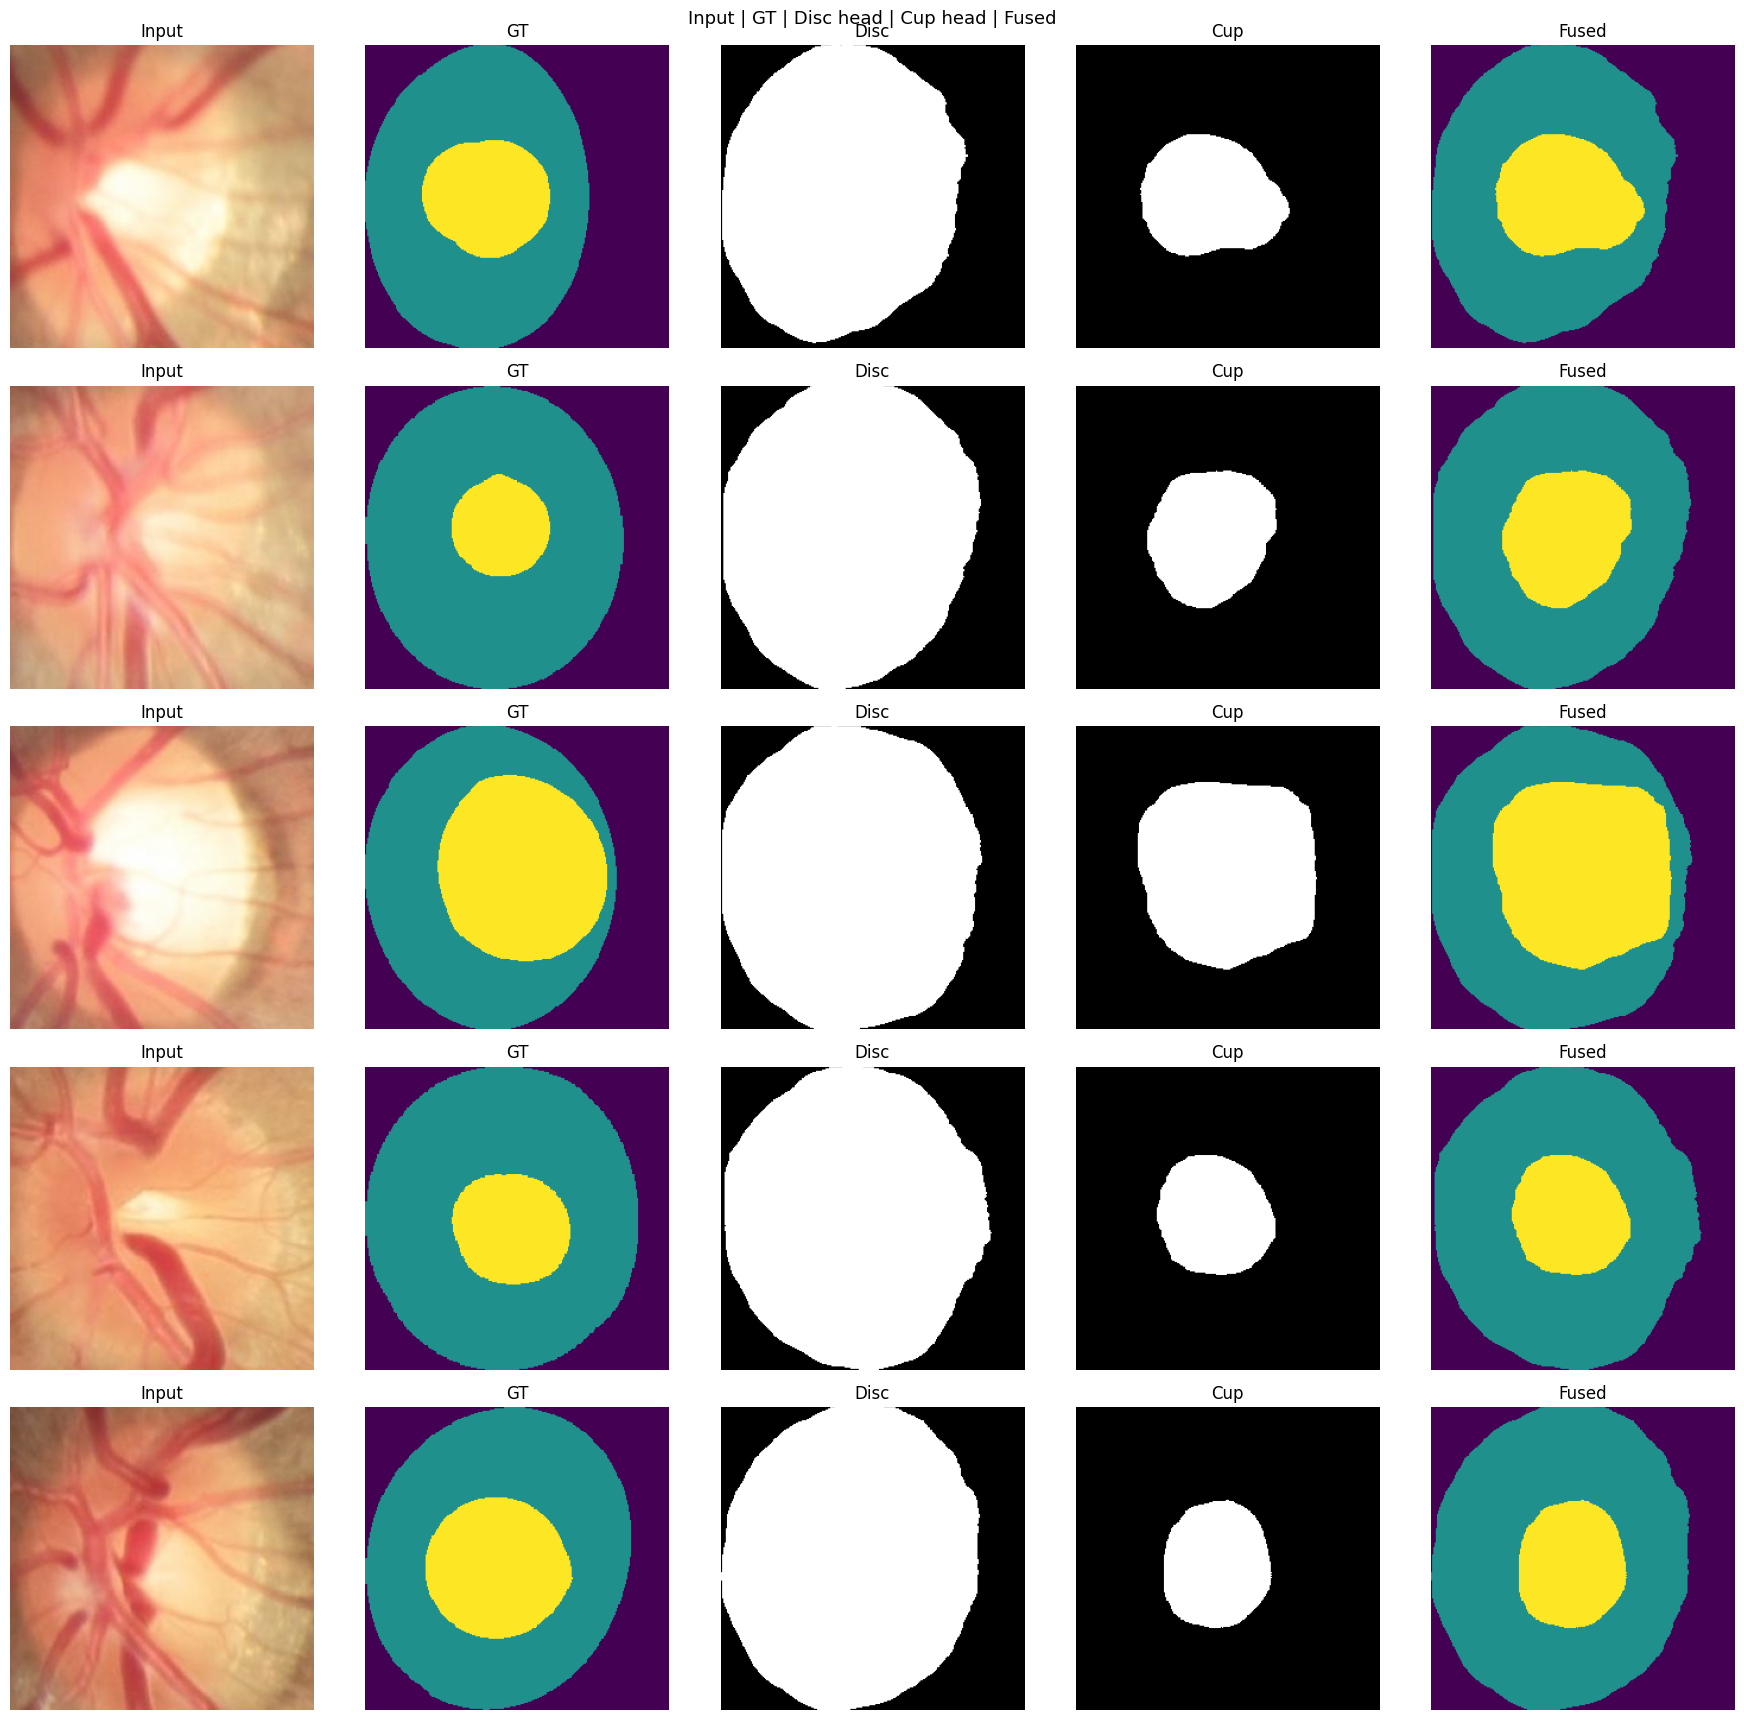

In [17]:
# ============================================================
# CELL 12 — Visualize predictions
# Columns: input | GT (3-class) | disc head | cup head | fused 3-class
# ============================================================
MEAN = np.array([0.485,0.456,0.406]); STD = np.array([0.229,0.224,0.225])

@torch.no_grad()
def visualize(dataset, n=5):
    model.eval()
    idxs = random.sample(range(len(dataset)), n)
    fig, ax = plt.subplots(n, 5, figsize=(18, 3.5*n))
    fig.suptitle("Input | GT | Disc head | Cup head | Fused", fontsize=13)
    for r, idx in enumerate(idxs):
        image, mask3 = dataset[idx]
        out_disc, out_cup = model(image.unsqueeze(0).to(DEVICE))
        disc_p = torch.argmax(out_disc,1)[0].cpu().numpy()
        cup_p  = torch.argmax(out_cup, 1)[0].cpu().numpy()
        fused  = disc_p.copy().astype(np.uint8); fused[(cup_p==1)&(disc_p==1)] = 2
        img_show = (image.permute(1,2,0).cpu().numpy()*STD + MEAN).clip(0,1)
        for c,(im,ttl,kw) in enumerate([
            (img_show,"Input",{}),
            (mask3.numpy(),"GT",{"cmap":"viridis","vmin":0,"vmax":2}),
            (disc_p,"Disc",{"cmap":"gray","vmin":0,"vmax":1}),
            (cup_p,"Cup",{"cmap":"gray","vmin":0,"vmax":1}),
            (fused,"Fused",{"cmap":"viridis","vmin":0,"vmax":2})]):
            ax[r,c].imshow(im, **kw); ax[r,c].set_title(ttl); ax[r,c].axis("off")
    plt.tight_layout(); plt.savefig("/kaggle/working/dualunet_xattn_predictions.png", dpi=100); plt.show()

visualize(test_ds, n=5)

In [18]:
# ============================================================
# CELL 13 — FULL RUN SUMMARY (everything in one place)
# Param count · input dimension · best TRAIN & VAL Dice (both pipelines)
# · best mean-FG · best-checkpoint epoch · TEST metrics (disc & cup)
# · FUSED 3-class (rim, cup) on test — using CELL 12's fusion rule.
# ============================================================
model.load_state_dict(torch.load(SAVE_PATH)); model.eval()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# ---- bests from history ----
val_mean  = history["val_mean_fg"]
best_ep   = int(np.argmax(val_mean))
best_mean = val_mean[best_ep]
peak_val_disc = max(history["val_disc_dice_c1"]);  peak_val_cup = max(history["val_cup_dice_c1"])
peak_tr_disc  = max(history["train_disc_dice_c1"]); peak_tr_cup = max(history["train_cup_dice_c1"])
ckpt_val_disc = history["val_disc_dice_c1"][best_ep];  ckpt_val_cup = history["val_cup_dice_c1"][best_ep]
ckpt_tr_disc  = history["train_disc_dice_c1"][best_ep]; ckpt_tr_cup = history["train_cup_dice_c1"][best_ep]

# ---- TEST (same evaluate_dual as CELL 11) ----
criterion = CombinedLoss(2)
test_loss, test_disc, test_cup = evaluate_dual(model, test_loader, criterion)
test_mean_fg = (test_disc["dice"][1] + test_cup["dice"][1]) / 2

# ---- FUSED 3-class on test (rim=1, cup=2) — SAME fusion as CELL 12 ----
@torch.no_grad()
def fused_test_dice(dataset, smooth=1e-6):
    tp = np.zeros(3); fp = np.zeros(3); fn = np.zeros(3)
    for i in range(len(dataset)):
        image, mask3 = dataset[i]
        out_disc, out_cup = model(image.unsqueeze(0).to(DEVICE))
        disc_p = torch.argmax(out_disc, 1)[0].cpu().numpy()
        cup_p  = torch.argmax(out_cup,  1)[0].cpu().numpy()
        fused  = disc_p.copy().astype(np.uint8)
        fused[(cup_p == 1) & (disc_p == 1)] = 2
        gt = mask3.numpy()
        for c in range(3):
            p, g = (fused == c), (gt == c)
            tp[c] += np.logical_and(p, g).sum()
            fp[c] += np.logical_and(p, ~g).sum()
            fn[c] += np.logical_and(~p, g).sum()
    return (2*tp + smooth) / (2*tp + fp + fn + smooth)

fused = fused_test_dice(test_ds)
fused_rim, fused_cup = fused[1], fused[2]; fused_mean = (fused_rim + fused_cup) / 2

# ---------------- PRINT ----------------
print("="*62)
print("  DUAL-DECODER U-NET + CROSS-ATTENTION — FULL RUN SUMMARY")
print(f"  Input dimension : {IMG_SIZE} x {IMG_SIZE}")
print(f"  Trainable params: {n_params:,}")
print(f"  Cross-attention : ON (bidirectional, coarsest stage) | Containment λ = {LAMBDA_CONTAIN}")
print(f"  Best checkpoint : epoch {best_ep+1}  (selected on val mean-FG)")
print("="*62)
print("  BEST VALIDATION Dice (foreground)")
print(f"    DISC pipeline  : peak {peak_val_disc:.4f}  | @best-ckpt {ckpt_val_disc:.4f}")
print(f"    CUP  pipeline  : peak {peak_val_cup:.4f}  | @best-ckpt {ckpt_val_cup:.4f}")
print(f"    MEAN(disc,cup) : best {best_mean:.4f}")
print("-"*62)
print("  BEST TRAIN Dice (foreground)")
print(f"    DISC pipeline  : peak {peak_tr_disc:.4f}  | @best-ckpt {ckpt_tr_disc:.4f}")
print(f"    CUP  pipeline  : peak {peak_tr_cup:.4f}  | @best-ckpt {ckpt_tr_cup:.4f}")
print("-"*62)
print("  TEST (best checkpoint) — pipelines reported SEPARATELY")
print(f"    DISC : Dice {test_disc['dice'][1]:.4f} | IoU {test_disc['iou'][1]:.4f} | P {test_disc['precision'][1]:.4f} | R {test_disc['recall'][1]:.4f}")
print(f"    CUP  : Dice {test_cup['dice'][1]:.4f} | IoU {test_cup['iou'][1]:.4f} | P {test_cup['precision'][1]:.4f} | R {test_cup['recall'][1]:.4f}")
print(f"    MEAN(disc,cup) Dice : {test_mean_fg:.4f}")
print("-"*62)
print("  TEST — FUSED 3-class (cup \u2286 disc):  rim=1, cup=2")
print(f"    Rim  Dice          : {fused_rim:.4f}")
print(f"    Cup  Dice          : {fused_cup:.4f}")
print(f"    MEAN(rim,cup) Dice : {fused_mean:.4f}")
print("="*62)

  DUAL-DECODER U-NET + CROSS-ATTENTION — FULL RUN SUMMARY
  Input dimension : 256 x 256
  Trainable params: 45,341,380
  Cross-attention : ON (bidirectional, coarsest stage) | Containment λ = 0.5
  Best checkpoint : epoch 97  (selected on val mean-FG)
  BEST VALIDATION Dice (foreground)
    DISC pipeline  : peak 0.9667  | @best-ckpt 0.9667
    CUP  pipeline  : peak 0.8796  | @best-ckpt 0.8796
    MEAN(disc,cup) : best 0.9231
--------------------------------------------------------------
  BEST TRAIN Dice (foreground)
    DISC pipeline  : peak 0.9789  | @best-ckpt 0.9765
    CUP  pipeline  : peak 0.8952  | @best-ckpt 0.8882
--------------------------------------------------------------
  TEST (best checkpoint) — pipelines reported SEPARATELY
    DISC : Dice 0.9645 | IoU 0.9315 | P 0.9539 | R 0.9755
    CUP  : Dice 0.8684 | IoU 0.7684 | P 0.8134 | R 0.9338
    MEAN(disc,cup) Dice : 0.9165
--------------------------------------------------------------
  TEST — FUSED 3-class (cup ⊆ disc): 